### Import modules and data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Setting up the path to include the parent directory
sys.path.append(str(Path.cwd().parent.parent))
from backend.config.settings import PATHS

In [2]:
water_path = PATHS['raw_data_notebooks'] / 'water.csv'
water_pd = pd.read_csv(water_path)
water_pd.head()

,DATE,CURRENT_WATER,ID
0,04/09/12 00:00,56.0,18
1,23/10/12 00:00,50.0,18
2,27/11/12 00:00,55.0,18
3,22/01/91 00:00,53.0,18
4,21/05/91 00:00,52.0,18


In [3]:
water_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 683447 entries, 0 to 683446
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   DATE           683447 non-null  object 
 1   CURRENT_WATER  683445 non-null  float64
 2   ID             683447 non-null  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 15.6+ MB


### Renaming columns

In [4]:
columns_dict = {'DATE': 'date', 'CURRENT_WATER': 'storage', 'ID': 'id'}
water_pd.rename(columns=columns_dict, inplace=True)

In [5]:
water_pd.head()

,date,storage,id
0,04/09/12 00:00,56.0,18
1,23/10/12 00:00,50.0,18
2,27/11/12 00:00,55.0,18
3,22/01/91 00:00,53.0,18
4,21/05/91 00:00,52.0,18


### Date column to datetime

In [6]:
# The exact time is irrelevant
water_pd_split = water_pd['date'].str.rsplit(pat='/', n=1, expand=True)
print(f"We split the dataframe conveniently: \n{water_pd_split}")
year_counts = water_pd_split[1].str.split(' ').str[0].value_counts().sort_index()

We split the dataframe conveniently: 
            0         1
0       04/09  12 00:00
1       23/10  12 00:00
2       27/11  12 00:00
3       22/01  91 00:00
4       21/05  91 00:00
...       ...       ...
683442  24/05  22 00:00
683443  21/06  22 00:00
683444  06/09  22 00:00
683445  27/09  22 00:00
683446  17/01  23 00:00

[683447 rows x 2 columns]


#### Visualize the distribution of years

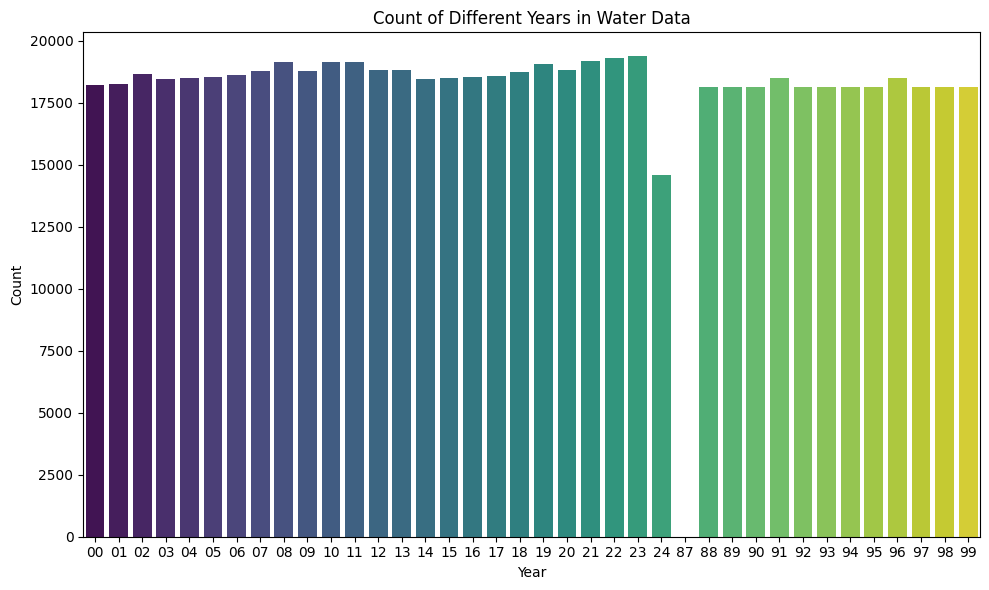

In [7]:
# Seaborn barplot to visualize the count of different years
plt.figure(figsize=(10, 6))
sns.barplot(x=year_counts.index, y=year_counts.values, hue=year_counts.index, palette='viridis', legend=False)
plt.title('Count of Different Years in Water Data')
plt.xlabel('Year')
plt.ylabel('Count')
plt.tight_layout()

### The 85 threshold has been decided in the EDA file. To ease the comprehension of this notebook, the plot has been done here too

In [8]:
two_digit_years = water_pd_split[1].str.split(' ').str[0].astype(int)
print(f"Two digit years: \n{two_digit_years}")

complete_years = two_digit_years.apply(lambda x: x + 1900 if x >= 85 else x + 2000)
print(f"Full years: \n{complete_years}")

Two digit years: 
0         12
1         12
2         12
3         91
4         91
          ..
683442    22
683443    22
683444    22
683445    22
683446    23
Name: 1, Length: 683447, dtype: int32
Full years: 
0         2012
1         2012
2         2012
3         1991
4         1991
          ... 
683442    2022
683443    2022
683444    2022
683445    2022
683446    2023
Name: 1, Length: 683447, dtype: int64


In [9]:
definite_date_column = water_pd_split[0] + '/' + complete_years.astype(str)
print(f"Definite date column: \n {definite_date_column}")

water_pd['date'] = pd.to_datetime(definite_date_column, format='%d/%m/%Y')

Definite date column: 
 0         04/09/2012
1         23/10/2012
2         27/11/2012
3         22/01/1991
4         21/05/1991
             ...    
683442    24/05/2022
683443    21/06/2022
683444    06/09/2022
683445    27/09/2022
683446    17/01/2023
Length: 683447, dtype: object


### Save current cleaning and developing water.ipynb at EDA folder

In [10]:
cleaned_water_path = PATHS['pre_EDA'] / 'water_for_EDA.csv'
cleaned_water_path.parent.mkdir(parents=True, exist_ok=True)
water_pd.to_csv(cleaned_water_path, index=False)

### Handling Missing Values as concluded at EDA

In [11]:
water_pd.isna().sum()

date       0
storage    2
id         0
dtype: int64

In [12]:
# As there are only two rows with missing storage, we can drop them (maybe interpolate them later)
water_pd = water_pd.dropna()
water_pd.isna().sum()

date       0
storage    0
id         0
dtype: int64

### Setting index every week, and treating NaNs as stated at EDA

In [13]:
filter_mask = ((water_pd['id'] == 396) & (water_pd['date'].dt.year < 2005)) | ((water_pd['id'] == 376) & (water_pd['date'].dt.year < 2012))
water_pd_filtered = water_pd[filter_mask == False]
water_pd_filtered

,date,storage,id
0,2012-09-04,56.0,18
1,2012-10-23,50.0,18
2,2012-11-27,55.0,18
3,1991-01-22,53.0,18
4,1991-05-21,52.0,18
...,...,...,...
683442,2022-05-24,1.0,743
683443,2022-06-21,1.0,743
683444,2022-09-06,1.0,743
683445,2022-09-27,1.0,743


In [14]:
def reindex_weekly(group): # This function is applied to every reservoir
    group_id = group.name
    # Create a complete weekly date range for this id
    full_range = pd.date_range(start=group['date'].min(), end=group['date'].max(), freq='7D')
    group = group.set_index('date').reindex(full_range)
    group['id'] = group_id
    group = group.reset_index().rename(columns={'index': 'date'})
    return group

In [15]:
# Drop id before groupby to avoid a future warning (even though the one we apply groupby to has the id column)
water_pd_filtered_full = water_pd_filtered.drop(columns=['id']).groupby(water_pd_filtered['id'], group_keys=False).apply(reindex_weekly)

### Add an imputed feature to be able to know in the future if the storage was filled

In [16]:
water_pd_filtered_full['storage_imputed'] = water_pd_filtered_full['storage'].isna().astype(int)

### Fill backward the imputed values

In [17]:
water_pd_filtered_full.loc[:, 'storage'] = water_pd_filtered_full['storage'].fillna(method='bfill')
water_pd_filtered_full

C:\Users\usuario\AppData\Local\Temp\ipykernel_16984\2902176649.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  water_pd_filtered_full.loc[:, 'storage'] = water_pd_filtered_full['storage'].fillna(method='bfill')


,date,storage,id,storage_imputed
0,1988-01-05,103.0,1,0
1,1988-01-12,103.0,1,0
2,1988-01-19,103.0,1,0
3,1988-01-26,103.0,1,0
4,1988-02-02,103.0,1,0
...,...,...,...,...
1912,2024-08-27,16.0,744,0
1913,2024-09-03,16.0,744,0
1914,2024-09-10,16.0,744,0
1915,2024-09-17,16.0,744,0


### Converting storage to Integer

In [18]:
water_pd = water_pd_filtered_full
# Let's ensure that every float is actually an int
print(f"Number of rows: {len(water_pd)}")
print(f"Number of int at storage: {len(water_pd[water_pd['storage'] % 1 == 0])}")

Number of rows: 683345
Number of int at storage: 683345


In [19]:
water_pd['storage'] = water_pd['storage'].astype(int)

### Saving cleaned data

In [20]:
cleaned_water_path = PATHS['cleaned_data_notebooks'] / 'water_cleaned.parquet'
cleaned_water_path.parent.mkdir(parents=True, exist_ok=True)
water_pd.to_parquet(cleaned_water_path, index=False)